# 📊 01 - Exploration du Dataset Sports

Ce notebook explore le dataset **100 Sports Image Classification** avant l'entraînement.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

# Chemins
DATA_DIR = '../data/sports'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')

print("Répertoire courant:", os.getcwd())

Répertoire courant: C:\Users\gongue\Desktop\sports-classifier\notebooks


## 1. Structure du dataset

In [3]:
# Vérifier les dossiers
for split in ['train', 'valid', 'test']:
    path = os.path.join(DATA_DIR, split)
    if os.path.exists(path):
        classes = os.listdir(path)
        print(f"{split}: {len(classes)} classes")
        # Compter images
        total = sum(len(os.listdir(os.path.join(path, c))) for c in classes if os.path.isdir(os.path.join(path, c)))
        print(f"  → {total} images")

train: 100 classes
  → 13493 images
valid: 100 classes
  → 500 images
test: 100 classes
  → 500 images


## 2. Distribution des classes

C:\Users\gongue\AppData\Local\Temp\ipykernel_8996\3684737125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='Count', y='Sport', palette='viridis')


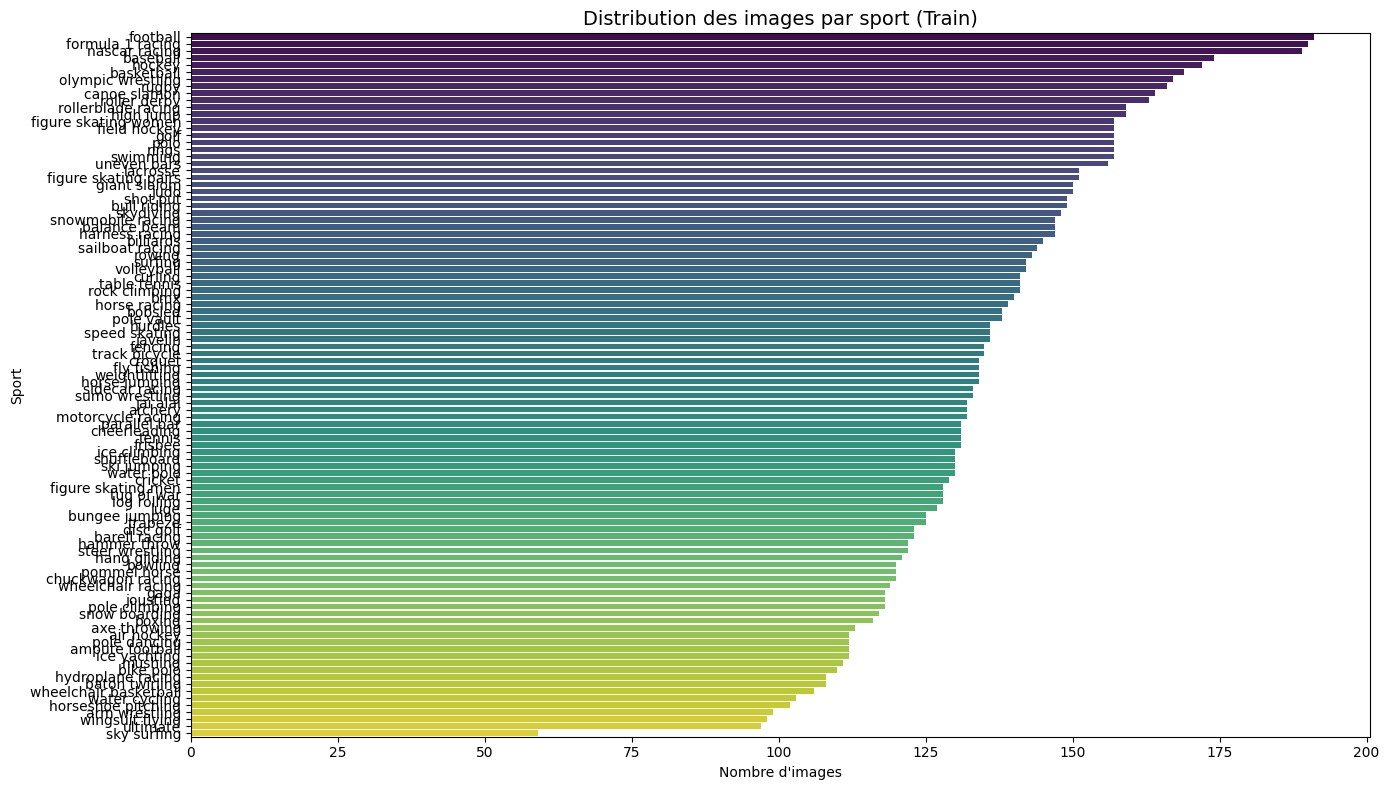

Moyenne: 134.9 images/classe
Min: 59, Max: 191


In [5]:
# Compter images par classe (train)
class_counts = {}
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Sport', 'Count'])
df_counts = df_counts.sort_values('Count', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(data=df_counts, x='Count', y='Sport', palette='viridis')
plt.title('Distribution des images par sport (Train)', fontsize=14)
plt.xlabel('Nombre d\'images')
plt.tight_layout()
plt.show()

print(f"Moyenne: {df_counts['Count'].mean():.1f} images/classe")
print(f"Min: {df_counts['Count'].min()}, Max: {df_counts['Count'].max()}")

## 3. Visualisation d'exemples

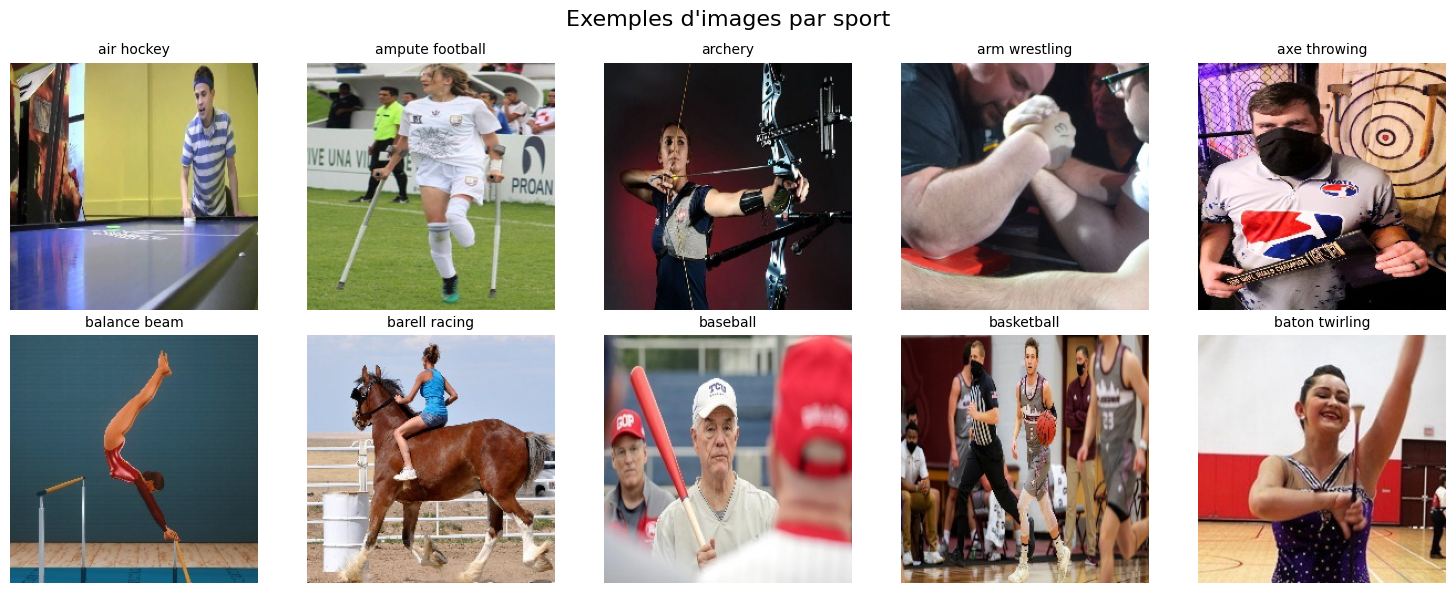

In [7]:
# Afficher 5 images aléatoires par classe (échantillon)
classes = sorted(os.listdir(TRAIN_DIR))[:10]  # 10 premières classes

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Exemples d\'images par sport', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Dimensions des images

In [9]:
# Vérifier quelques dimensions
dims = []
for cls in list(class_counts.keys())[:5]:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_path)[:5]:
        img = Image.open(os.path.join(cls_path, img_name))
        dims.append(img.size)

widths, heights = zip(*dims)
print(f"Dimensions uniques trouvées: {set(dims)}")
print(f"Toutes les images sont en 224x224: {all(w == 224 and h == 224 for w, h in dims)}")

Dimensions uniques trouvées: {(224, 224)}
Toutes les images sont en 224x224: True


## 5. Conclusions

- Dataset bien structuré avec split train/valid/test
- 100 classes équilibrées (~130 images/classe)
- Images déjà en 224×224 → prêt pour MobileNetV2
- Pas de déséquilibre majeur détecté